In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [1]:
!pip install tensorflow keras numpy matplotlib scikit-learn


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("All libraries imported successfully ✅")

TensorFlow version: 2.20.0
NumPy version: 2.0.2
All libraries imported successfully ✅


In [3]:
!pip freeze > requirements.txt

In [4]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<!-- Task 2: Research Neural Network Concepts -->
1. Neural Network :
A Neural Network is a computing system inspired by the structure and functioning of the human brain. It consists of interconnected nodes called neurons that process information, learn patterns from data, and make predictions.
Each neuron receives input, processes it using weights and biases, applies an activation function, and passes the output to the next layer.
Neural networks are the foundation of Deep Learning and are widely used for solving complex problems such as image recognition, speech processing, and natural language understanding.

eg.:Face recognition in smartphones .
    Voice assistants like Siri and Google Assistant .
    Self-driving cars detecting objects on the road .

2.Layers in Neural Networks :
A neural network is structured in layers, and each layer has a specific role.
Input Layer :
The input layer is the first layer of a neural network. It receives raw data and passes it to the next layer for processing.
Each node represents one feature in the dataset.
No computation happens here.
It simply forwards data.

Eg.:
If we are predicting house prices:
Input features = size, location, number of rooms.

Hidden Layer :
Hidden layers are the core of a neural network where learning happens.
They perform mathematical transformations on inputs.
They extract patterns and features from data.
A network with many hidden layers is called a Deep Neural Network.
eg.:Example:
In image recognition:
First layer detects edges
Middle layers detect shapes
Deep layers detect objects like faces

Output Layer:
The output layer produces the final result of the model.
It depends on the type of problem:
Binary classification → 1 neuron (0 or 1)
Multi-class classification → multiple neurons
Regression → single continuous value

Example:
Email classification → Spam / Not Spam
Digit recognition → 0–9 classification

3. Activation Functions :
Activation functions introduce non-linearity into the model. Without them, the neural network would behave like a simple linear model.
ReLU (Rectified Linear Unit)

Formula:

f(x) = max(0, x)
If input is negative → output is 0
If input is positive → output is same value

Advantages:

Fast computation
Reduces vanishing gradient problem
Most commonly used activation function

Sigmoid Function

Formula:

1 / (1 + e^(-x))
Output range: 0 to 1
Converts values into probabilities

Advantages:
Good for binary classification
Disadvantages:
Vanishing gradient problem
Slower convergence

Tanh Function

Formula:

(-1 to +1 output)
Similar to sigmoid but centered around zero
Advantages:
Better than sigmoid for hidden layers
Helps with negative and positive values
Disadvantages:
Still suffers from vanishing gradient problem

Softmax Function :
Softmax converts raw outputs into probabilities that sum to 1.

Example:
Class A → 0.1
Class B → 0.7
Class C → 0.2
Advantages:
Best for multi-class classification

4. Training Concepts in Neural Networks :
Training is the process where the model learns patterns from data by adjusting weights.
Epoch :

An epoch is one complete pass through the entire training dataset.

Example:

If dataset has 1000 samples:
1 epoch = model sees all 1000 samples once
 More epochs → better learning
Too many epochs → overfitting

Batch Size :
Batch size is the number of samples processed before updating model weights.
Example:
Dataset = 1000 samples
Batch size = 100
Model updates weights 10 times per epoch

Small batch size → better generalization
Large batch size → faster training

Learning Rate:

Learning rate controls how much the model updates weights during training.
High learning rate → fast but unstable learning
Low learning rate → slow but accurate learning
Finding the right learning rate is very important for performance.

Loss Function:

A loss function measures how wrong the model’s predictions are.
Goal: Minimize loss
Common loss functions:
Mean Squared Error (Regression)
Cross-Entropy Loss (Classification)
Lower loss = better model performance

Optimizer :

An optimizer updates model weights to reduce loss.
Popular optimizers:
SGD (Stochastic Gradient Descent)
Adam (most commonly used)
RMSProp
Adam optimizer is widely used because it adapts learning rate automatically

Gradient Descent :

Gradient Descent is the core algorithm used to train neural networks.
Steps:
Model makes prediction
Calculate error (loss)
Compute gradient (direction of error)
Update weights
Repeat until loss is minimized
This process helps the model gradually improve accuracy.



In [13]:
# Task 3: Build Your First Neural Network
# Step 1: Load Dataset
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Step 2: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 3: Normalize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Build Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),  # Input + hidden layer
    Dense(8, activation='relu'),                     # Hidden layer
    Dense(3, activation='softmax')                   # Output layer
])

# Step 5: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# Step 7: Make Predictions
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predicted classes:", y_pred_classes[:10])
print("Actual classes:", y_test[:10])

# Step 8: Display Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_classes)

print("Model Accuracy:", accuracy)

Shape of X: (150, 4)
Shape of y: (150,)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.0312 - loss: 1.3998 - val_accuracy: 0.0000e+00 - val_loss: 1.4639
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0312 - loss: 1.3706 - val_accuracy: 0.0000e+00 - val_loss: 1.4220
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0417 - loss: 1.3392 - val_accuracy: 0.0000e+00 - val_loss: 1.3831
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0312 - loss: 1.3111 - val_accuracy: 0.0833 - val_loss: 1.3460
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0312 - loss: 1.2850 - val_accuracy: 0.0833 - val_loss: 1.3101
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0417 - loss: 1.2600 - val_accuracy: 0.0833 - val_loss: 1.2762
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0938 - loss: 1.2347 - val_accuracy: 0.0833 - val_loss: 1.2460
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0938 - loss: 1.2121 - val_accuracy: 0.1250 - val_loss: 1.217

In [20]:
# Task 4: Model Experiments

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to create neural network
def build_model(hidden_layers=1, neurons=16, activation='relu'):

    model = Sequential()

    # First hidden layer
    model.add(
        Dense(
            neurons,
            activation=activation,
            input_shape=(4,)
        )
    )

    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(
            Dense(
                neurons,
                activation=activation
            )
        )

    # Output layer
    model.add(
        Dense(
            3,
            activation='softmax'
        )
    )

    # Compile model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Different experiments
experiments = [
    {
        "layers": 1,
        "neurons": 8,
        "activation": "relu",
        "epochs": 20
    },
    {
        "layers": 2,
        "neurons": 16,
        "activation": "relu",
        "epochs": 50
    },
    {
        "layers": 3,
        "neurons": 32,
        "activation": "relu",
        "epochs": 100
    },
    {
        "layers": 2,
        "neurons": 16,
        "activation": "tanh",
        "epochs": 50
    }
]

results = []

# Train models
for exp in experiments:

    print("\nTraining Model")
    print(exp)

    model = build_model(
        hidden_layers=exp["layers"],
        neurons=exp["neurons"],
        activation=exp["activation"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=exp["epochs"],
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append({
        "Layers": exp["layers"],
        "Neurons": exp["neurons"],
        "Activation": exp["activation"],
        "Epochs": exp["epochs"],
        "Accuracy": accuracy
    })

    print("Accuracy:", round(accuracy, 4))

# Display comparison results
print("\n" + "="*50)
print("MODEL COMPARISON RESULTS")
print("="*50)

for result in results:
    print(
        f"Layers: {result['Layers']}, "
        f"Neurons: {result['Neurons']}, "
        f"Activation: {result['Activation']}, "
        f"Epochs: {result['Epochs']}, "
        f"Accuracy: {result['Accuracy']:.4f}"
    )

# Find best model
best_model = max(results, key=lambda x: x["Accuracy"])

print("\nBest Performing Model")
print(best_model)


Training Model
{'layers': 1, 'neurons': 8, 'activation': 'relu', 'epochs': 20}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.3667

Training Model
{'layers': 2, 'neurons': 16, 'activation': 'relu', 'epochs': 50}
Accuracy: 0.9333

Training Model
{'layers': 3, 'neurons': 32, 'activation': 'relu', 'epochs': 100}
Accuracy: 1.0

Training Model
{'layers': 2, 'neurons': 16, 'activation': 'tanh', 'epochs': 50}
Accuracy: 0.9667

MODEL COMPARISON RESULTS
Layers: 1, Neurons: 8, Activation: relu, Epochs: 20, Accuracy: 0.3667
Layers: 2, Neurons: 16, Activation: relu, Epochs: 50, Accuracy: 0.9333
Layers: 3, Neurons: 32, Activation: relu, Epochs: 100, Accuracy: 1.0000
Layers: 2, Neurons: 16, Activation: tanh, Epochs: 50, Accuracy: 0.9667

Best Performing Model
{'Layers': 3, 'Neurons': 32, 'Activation': 'relu', 'Epochs': 100, 'Accuracy': 1.0}


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.3125 - loss: 1.1543 - val_accuracy: 0.2083 - val_loss: 1.1710
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3854 - loss: 1.1219 - val_accuracy: 0.2083 - val_loss: 1.1477
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4167 - loss: 1.0876 - val_accuracy: 0.2500 - val_loss: 1.1265
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4896 - loss: 1.0575 - val_accuracy: 0.2500 - val_loss: 1.1069
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4792 - loss: 1.0307 - val_accuracy: 0.3333 - val_loss: 1.0882
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5104 - loss: 1.0050 - val_accuracy: 0.3333 - val_loss: 1.0712
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5104 - loss: 0.9816 - val_accuracy: 0.3333 - val_loss: 1.0556
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5312 - loss: 0.9600 - val_accuracy: 0.3333 - val_loss: 1.0407
Epoch 9/50

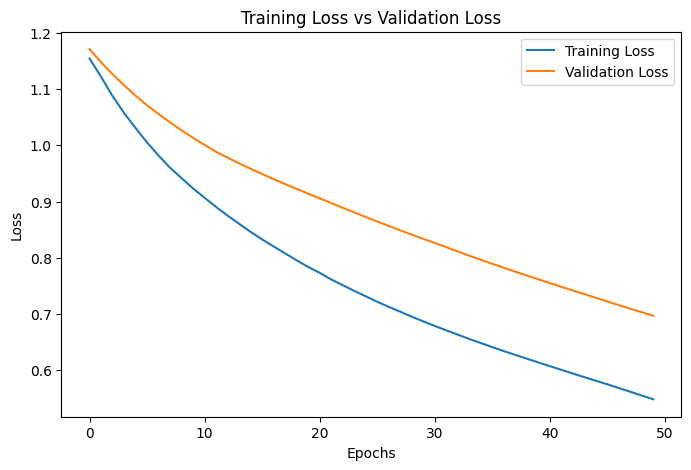

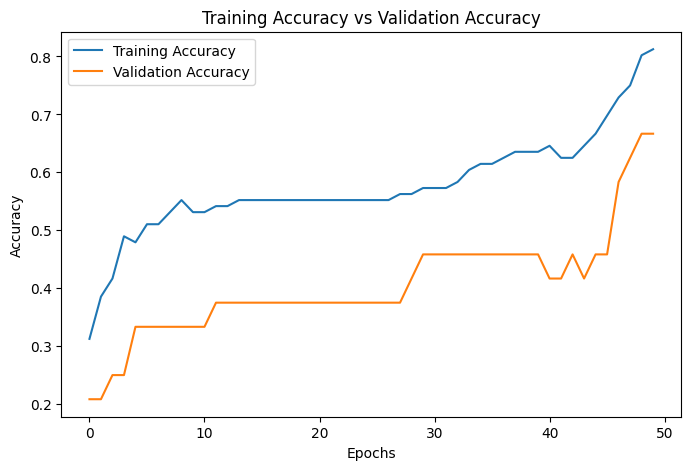

Graphs saved successfully!


In [21]:
# Task 5: Training Visualization
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# ----------------------------
# LOSS GRAPH
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('loss_graph.png')
plt.show()

# ----------------------------
# ACCURACY GRAPH
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('accuracy_graph.png')
plt.show()

print("Graphs saved successfully!")

In [22]:
from google.colab import files

files.download("loss_graph.png")
files.download("accuracy_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# Task 6: MNIST Digit Classifier
# Step 1: Load Dataset
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Step 2: Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 3: Build Neural Network
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 4: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Step 5: Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

# Step 6: Evaluate Accuracy
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# Step 7: Predict Sample Images
predictions = model.predict(X_test[:5])

for i in range(5):

    predicted_digit = np.argmax(predictions[i])
    confidence = np.max(predictions[i])

    print(f"\nSample {i+1}")
    print("Actual Digit:", y_test[i])
    print("Predicted Digit:", predicted_digit)
    print("Confidence Score:", round(confidence * 100, 2), "%")

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9239 - loss: 0.2658 - val_accuracy: 0.9590 - val_loss: 0.1428
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9666 - loss: 0.1101 - val_accuracy: 0.9653 - val_loss: 0.1123
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9767 - loss: 0.0750 - val_accuracy: 0.9703 - val_loss: 0.0968
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0571 - val_accuracy: 0.9701 - val_loss: 0.0987
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9858 - loss: 0.0444 - val_accuracy: 0.9719 - val_loss: 0.0957
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9733 - loss: 0.0948

Test Accuracy: 0.9732999801635742
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step

Sample 1
Actual Digit: 7
Predicted Digit: 7
Confidence Score: 99.97 %

Sample 2
Actual Digit: 2
Predicted Digit: 2
Confidence Score:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


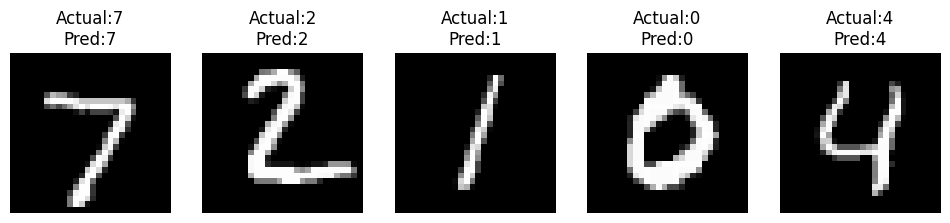

In [29]:
# Step 8: Display Images with Predictions
import matplotlib.pyplot as plt

predictions = model.predict(X_test[:5])

plt.figure(figsize=(12, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    predicted_digit = np.argmax(predictions[i])

    plt.title(
        f"Actual:{y_test[i]}\nPred:{predicted_digit}"
    )

    plt.axis('off')

plt.show()

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step

Sample 1
Actual Digit: 7
Predicted Digit: 7
Confidence Score: 99.97 %

Sample 2
Actual Digit: 2
Predicted Digit: 2
Confidence Score: 100.0 %

Sample 3
Actual Digit: 1
Predicted Digit: 1
Confidence Score: 99.82 %

Sample 4
Actual Digit: 0
Predicted Digit: 0
Confidence Score: 100.0 %

Sample 5
Actual Digit: 4
Predicted Digit: 4
Confidence Score: 100.0 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


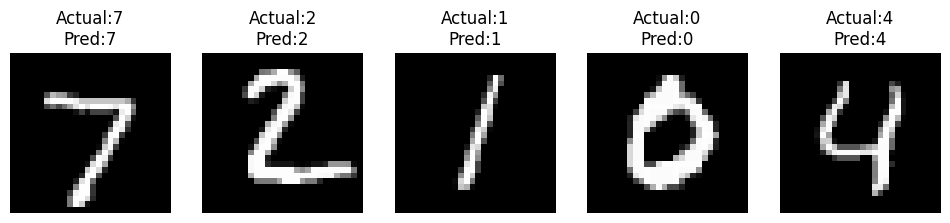

In [33]:
# Task 7: Model Saving and Loading
# Step 1: Save the Model
# Save model
model.save("digit_model.h5")

print("Model saved successfully!")

# Step 2: Download the Model
from google.colab import files

files.download("digit_model.h5")

# Step 3: Load the Saved Model
from tensorflow.keras.models import load_model

loaded_model = load_model("digit_model.h5")

print("Model loaded successfully!")

# Step 4: Make Predictions Without Retraining
import numpy as np

predictions = loaded_model.predict(X_test[:5])

for i in range(5):

    predicted_digit = np.argmax(predictions[i])
    confidence = np.max(predictions[i])

    print(f"\nSample {i+1}")
    print("Actual Digit:", y_test[i])
    print("Predicted Digit:", predicted_digit)
    print("Confidence Score:", round(confidence * 100, 2), "%")

# Step 5: Display Images and Predictions
import matplotlib.pyplot as plt

predictions = loaded_model.predict(X_test[:5])

plt.figure(figsize=(12, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    predicted_digit = np.argmax(predictions[i])

    plt.title(
        f"Actual:{y_test[i]}\nPred:{predicted_digit}"
    )

    plt.axis('off')

plt.show()



In [34]:
# model_management.py
from tensorflow.keras.models import load_model
import numpy as np

# Load saved model
loaded_model = load_model("digit_model.h5")

print("Model loaded successfully!")

# Predict first 5 test images
predictions = loaded_model.predict(X_test[:5])

for i in range(5):

    predicted_digit = np.argmax(predictions[i])
    confidence = np.max(predictions[i])

    print(f"\nSample {i+1}")
    print("Actual Digit:", y_test[i])
    print("Predicted Digit:", predicted_digit)
    print("Confidence Score:", round(confidence * 100, 2), "%")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step

Sample 1
Actual Digit: 7
Predicted Digit: 7
Confidence Score: 99.97 %

Sample 2
Actual Digit: 2
Predicted Digit: 2
Confidence Score: 100.0 %

Sample 3
Actual Digit: 1
Predicted Digit: 1
Confidence Score: 99.82 %

Sample 4
Actual Digit: 0
Predicted Digit: 0
Confidence Score: 100.0 %

Sample 5
Actual Digit: 4
Predicted Digit: 4
Confidence Score: 100.0 %


# Task 8: AI Engineering Analysis Report
# deep_learning_report.md.
Deep Learning Analysis Report
Introduction

Deep learning is a branch of artificial intelligence (AI) and machine learning that uses artificial neural networks to learn patterns from data. Unlike traditional machine learning techniques that often require manual feature engineering, deep learning models automatically learn useful features from raw data. Deep learning has become the foundation of many modern technologies, including image recognition, speech recognition, recommendation systems, autonomous vehicles, computer vision applications, and Large Language Models (LLMs) such as ChatGPT.

The success of deep learning comes from its ability to process large amounts of data and discover complex relationships that are difficult for humans to identify manually. Neural networks are inspired by the structure of the human brain and consist of interconnected layers of neurons that work together to perform predictions and classifications. Understanding how these models learn is essential for building advanced AI systems.

Why Do Deep Learning Models Require Large Datasets?

Deep learning models typically contain a large number of parameters, including weights and biases. These parameters must be learned during training. Because of the high number of parameters, deep learning models require large datasets to learn meaningful patterns and generalize effectively to unseen data.

When a dataset is small, a deep learning model may memorize the training examples instead of learning general patterns. This phenomenon is known as overfitting. Overfitting causes the model to perform well on training data but poorly on new data. Large datasets help reduce overfitting by exposing the model to a wide variety of examples.

For example, an image classification model trained on only a few hundred images may struggle to recognize objects in different lighting conditions, backgrounds, or angles. However, if the same model is trained on millions of images, it can learn more robust and generalized features.

Large datasets also help neural networks learn hierarchical representations. In image recognition, early layers learn simple features such as edges and shapes, while deeper layers learn complex features such as faces, animals, or objects. Learning these representations effectively requires significant amounts of data.

Modern AI systems such as ChatGPT are trained on enormous datasets containing books, websites, articles, and other text sources. The vast amount of data allows these models to understand language patterns, grammar, context, reasoning, and knowledge across many domains.

What Is the Role of Activation Functions?

Activation functions play a critical role in neural networks because they introduce non-linearity into the model. Without activation functions, a neural network would behave like a simple linear model regardless of how many layers it contains.

The primary purpose of an activation function is to determine whether a neuron should be activated based on its input. This allows neural networks to learn complex relationships and solve challenging problems.

Several activation functions are commonly used:

ReLU (Rectified Linear Unit)

ReLU is one of the most widely used activation functions in deep learning.

Formula:

f(x) = max(0, x)

Advantages:

Computationally efficient
Reduces the vanishing gradient problem
Speeds up training

ReLU is commonly used in hidden layers of deep neural networks and computer vision models.

Sigmoid

The sigmoid activation function converts values into a range between 0 and 1.

Advantages:

Useful for binary classification problems
Produces probability-like outputs

However, sigmoid can suffer from the vanishing gradient problem, making training difficult in deep networks.

Tanh

The tanh function outputs values between -1 and 1.

Advantages:

Centered around zero
Often performs better than sigmoid

However, tanh can still experience vanishing gradients in deep networks.

Softmax

Softmax is primarily used in the output layer of multi-class classification models.

Advantages:

Converts outputs into probabilities
Ensures all probabilities sum to one

For example, in digit classification, Softmax helps determine the probability that an image belongs to one of the ten digit classes.

Why Is Data Normalization Important?

Data normalization is a preprocessing technique used to scale features into a consistent range. It is an important step because neural networks are sensitive to the scale of input data.

When different features have significantly different ranges, the learning process becomes inefficient. For example, one feature may range from 0 to 1 while another ranges from 0 to 10,000. In such cases, the larger feature may dominate the learning process.

Normalization offers several benefits:

Faster Training

Normalized data allows gradient descent to converge more quickly because all features contribute more evenly during optimization.

Improved Stability

Large input values can produce unstable gradients and slow learning. Normalization helps maintain numerical stability.

Better Performance

Models trained on normalized data often achieve higher accuracy because the optimization process becomes more effective.

Reduced Training Time

Since the optimizer can find optimal weights more efficiently, training requires fewer iterations.

In image processing tasks such as MNIST digit recognition, pixel values range from 0 to 255. Dividing these values by 255 scales them into the range 0 to 1, making training faster and more stable.

How Does a Neural Network Learn?

A neural network learns through a process called training. During training, the model adjusts its weights and biases to minimize prediction errors.

The learning process consists of several steps:

Forward Propagation

Input data is passed through the network layer by layer. Each neuron performs calculations and generates outputs. The final output represents the model's prediction.

Loss Calculation

The prediction is compared with the actual target value using a loss function. The loss function measures how far the prediction is from the correct answer.

Examples include:

Mean Squared Error (MSE)
Binary Cross-Entropy
Categorical Cross-Entropy
Backpropagation

The network calculates how much each weight contributed to the error. Errors are propagated backward through the network.

Gradient Descent

The optimizer updates the weights using gradients computed during backpropagation. The objective is to reduce the loss function over time.

Repeated Learning

This process repeats for multiple epochs until the model achieves satisfactory performance.

As training progresses, the network gradually learns patterns and relationships in the data. The loss decreases while accuracy increases, indicating improved learning.

How Is Deep Learning Connected to Modern LLMs?

Large Language Models (LLMs) are advanced deep learning systems designed to understand and generate human language. Modern LLMs such as ChatGPT, GPT models, Gemini, and other conversational AI systems are built using deep learning techniques.

The foundation of LLMs is the artificial neural network. However, instead of simple feedforward networks, LLMs use a specialized architecture known as the Transformer. Transformers are deep neural networks that use self-attention mechanisms to understand relationships between words in a sentence.

Deep learning enables LLMs to:

Learn language patterns from massive datasets
Understand grammar and sentence structure
Generate coherent text
Perform translation and summarization
Answer questions
Assist with programming tasks

Training an LLM involves processing billions or even trillions of words. During training, the model learns to predict the next word in a sequence. Through this process, it develops an understanding of language, context, and reasoning.

Activation functions, optimization algorithms, normalization techniques, and backpropagation are all essential components used in training LLMs. Therefore, the concepts learned in basic neural networks directly contribute to understanding modern language models.

The progression from simple neural networks to deep neural networks and eventually to Transformer-based LLMs demonstrates how foundational deep learning principles support today's most advanced AI technologies.